In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 8)
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading (Fast Subset)
def load_all_data():
    all_data = []
    files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
    random.seed(42)
    random.shuffle(files)
    
    for file_path in files:
        if len(all_data) >= 100: # 100 stocks for a good sample size
            break
        symbol = os.path.basename(file_path).replace('.csv', '')
        try:
            df = pd.read_csv(file_path)
            df = df.dropna(subset=['Close'])
            
            if len(df) > 0:
                latest_price = df['Close'].iloc[-1]
                if latest_price < 90 or latest_price > 600:
                    continue
                    
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            df['Daily_Ret'] = df['Close'].pct_change()
            df = df[(df['Daily_Ret'].isna()) | (df['Daily_Ret'].abs() <= 0.20)]
            df['Symbol'] = symbol
            all_data.append(df)
        except Exception as e:
            pass
            
    return pd.concat(all_data, ignore_index=True)

data = load_all_data()


In [3]:
# 3. Calculate Strategy Metrics (Active Miner)
LOOKBACK = 13
HOLD_DAYS = 13

def enrich_data(df):
    df = df.copy()
    
    df['Fwd_Ret'] = df['Close'].shift(-HOLD_DAYS) / df['Close'] - 1
    
    # ER
    change = abs(df['Close'] - df['Close'].shift(LOOKBACK))
    volatility = df['Close'].diff().abs().rolling(LOOKBACK).sum()
    df['ER'] = change / volatility
    
    # WMA Dist
    weights = np.arange(1, LOOKBACK + 1)
    wma = df['Close'].rolling(LOOKBACK).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
    df['WMA_Dist'] = (df['Close'] - wma) / wma
        
    return df

_data_list = []
for sym, grp in data.groupby('Symbol'):
    _data_list.append(enrich_data(grp))
data = pd.concat(_data_list, ignore_index=True)

# Unseen Data Only
test_data = data[data['Date'] >= '2023-01-01'].dropna(subset=['Fwd_Ret', 'ER', 'WMA_Dist'])


In [4]:
# 4. Isolate Active Miner Trades
# Active Miner Rules: ER_13 > 0.4 | WMA_Dist < 10%
active_trades = test_data[(test_data['ER'] > 0.4) & (test_data['WMA_Dist'] < 0.10)]

active_trades['Trade_Result'] = np.where(active_trades['Fwd_Ret'] > 0, 'Win', 'Loss')

wins = active_trades[active_trades['Trade_Result'] == 'Win']
losses = active_trades[active_trades['Trade_Result'] == 'Loss']

display(HTML(f"<h2>Total Trades: {len(active_trades)}</h2>"))
display(HTML(f"<h3>Winning Trades: {len(wins)}</h3>"))
display(HTML(f"<h3>Losing Trades: {len(losses)}</h3>"))


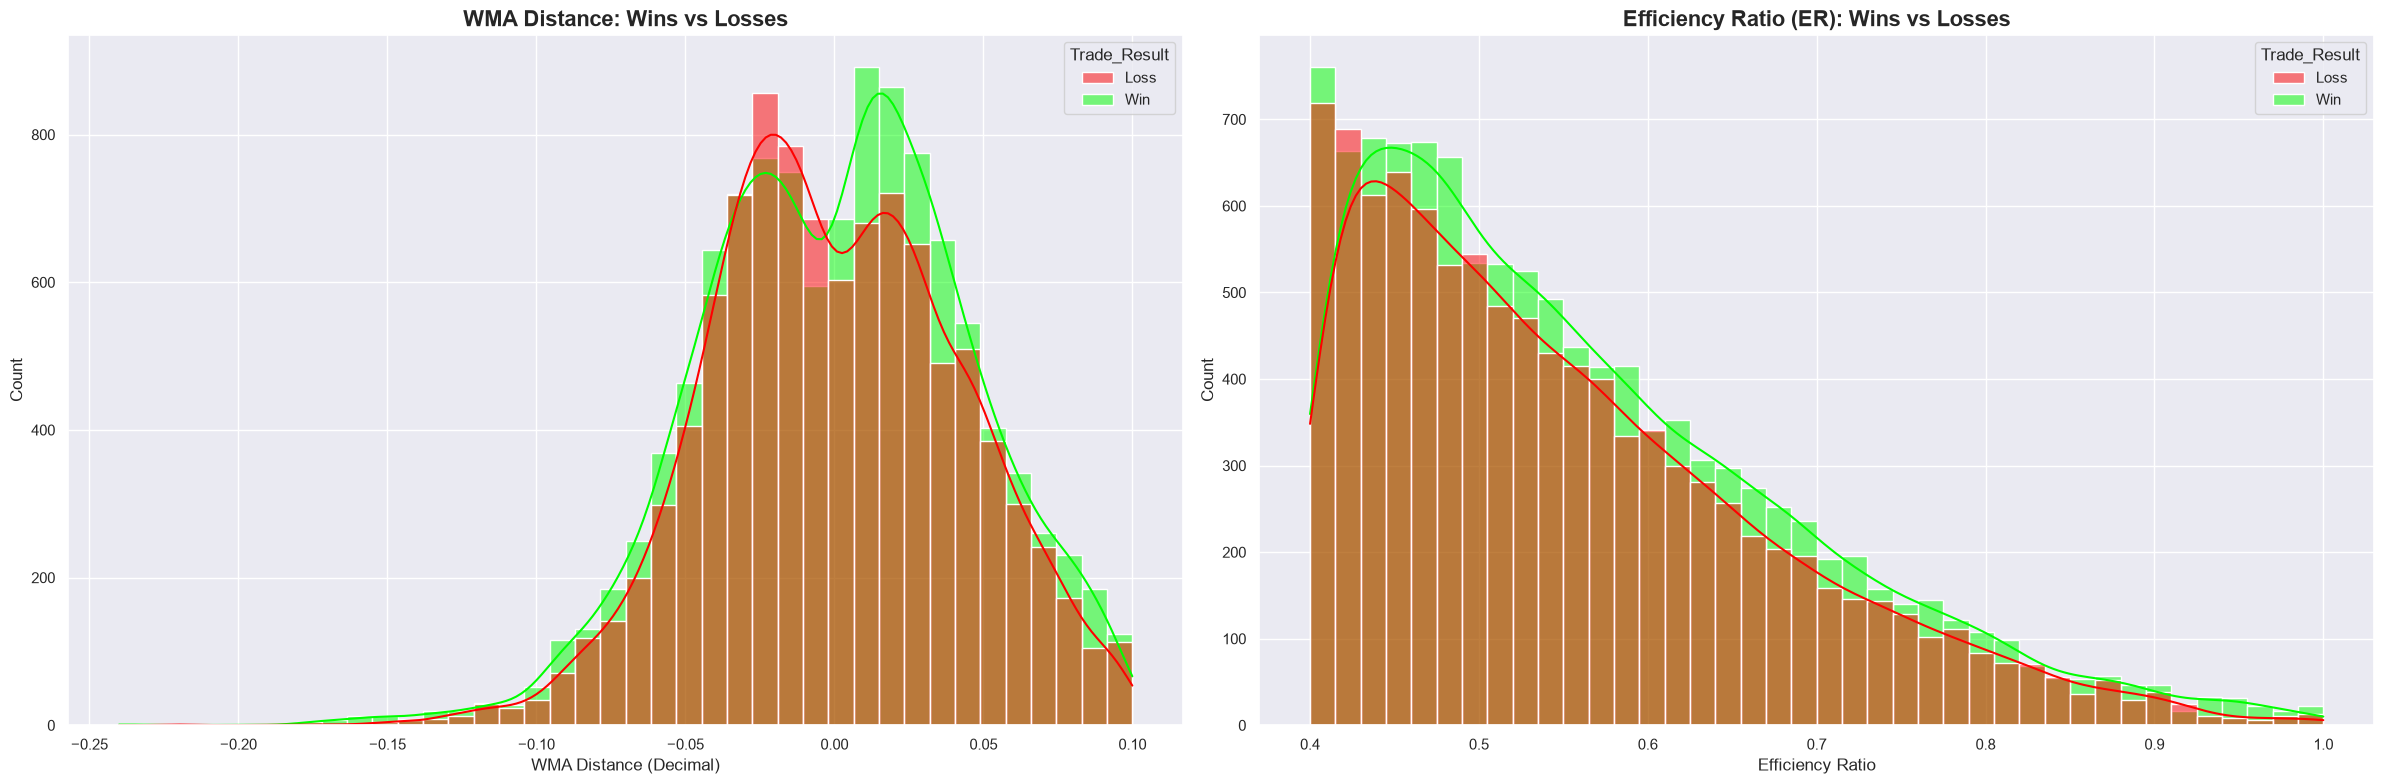

,count,mean,std,min,25%,50%,75%,max
ER,9962.0,0.55294,0.120339,0.400000,0.456087,0.525349,0.622911,1.000000
WMA_Dist,9962.0,-0.00031,0.042431,-0.223365,-0.029481,-0.002154,0.029518,0.099819


In [5]:
# 5. Analyze WMA and ER of the Losing Trades
fig, axs = plt.subplots(1, 2, figsize=(24, 8))

# WMA Distance Distribution
sns.histplot(data=active_trades, x='WMA_Dist', hue='Trade_Result', palette={'Win': 'lime', 'Loss': 'red'}, bins=40, kde=True, ax=axs[0])
axs[0].set_title('WMA Distance: Wins vs Losses', fontsize=16, fontweight='bold')
axs[0].set_xlabel('WMA Distance (Decimal)')

# ER Distribution
sns.histplot(data=active_trades, x='ER', hue='Trade_Result', palette={'Win': 'lime', 'Loss': 'red'}, bins=40, kde=True, ax=axs[1])
axs[1].set_title('Efficiency Ratio (ER): Wins vs Losses', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Efficiency Ratio')

plt.tight_layout()
plt.show()

# Print statistical summary of losing trades
display(HTML("<h3>Statistical Summary of Losing Trades</h3>"))
display(losses[['ER', 'WMA_Dist']].describe().T)
